# CBM vs Baseline: Do Concepts Move Deeper When We Supervise Them?

In the baseline ResNet-50, we found that most **attribute concepts** (colors, patterns, shapes)  
are most easily decoded from the **very first convolutional layer (conv1)**,  
while **species identity** emerges only at the deepest layer (layer4).

This raised a key question:

> If we _force_ the model to predict attributes (via a Concept Bottleneck Model),
> does that reorganize internal representations so that concepts are represented **deeper** and more **stably**,
> rather than as shallow texture signatures?

In this notebook we:

1. Load **baseline** and **CBM** probe results.
2. Compute **emergence depth** for each concept in each model.
3. Compare how emergence depth changes **per attribute** and **per attribute group**.
4. Interpret what this says about:
   - how standard CNNs use attributes, and  
   - what CBM training actually changes.


In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
# CELL 1 — Imports and configuration

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For nicer plots
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

# Paths (adjust if needed)
BASELINE_RESULT_PATH = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_RESULT_PATH      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

# Layer order used in feature extraction / probes
LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
LAYER_TO_INDEX = {layer: idx for idx, layer in enumerate(LAYER_ORDER)}

LAYER_ORDER


['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']

## 1. Load probe results for baseline and CBM

Each JSON file contains one row per probe:

- `layer`: which layer the probe was trained on  
- `target_type`: `"attribute"` or `"subclass"` (species)  
- `target_name`: e.g. `"has_breast_color::yellow"` or `"species"`  
- `group`: attribute group, e.g. `"has_breast_color"`  
- `best_val_acc`: best validation accuracy achieved for that probe  

We add a `model` column to distinguish baseline vs CBM.


In [4]:
# CELL 2 — Load baseline and CBM JSONs

assert BASELINE_RESULT_PATH.exists(), f"Baseline file not found: {BASELINE_RESULT_PATH}"
assert CBM_RESULT_PATH.exists(), f"CBM file not found: {CBM_RESULT_PATH}"

df_base = pd.read_json(BASELINE_RESULT_PATH)
df_cbm  = pd.read_json(CBM_RESULT_PATH)

df_base["model"] = "baseline"
df_cbm["model"]  = "cbm"

print("Baseline rows:", df_base.shape[0])
print("CBM rows:", df_cbm.shape[0])

df_base.head()


Baseline rows: 660
CBM rows: 660


,layer,target_type,target_name,group,train_acc,val_acc,best_val_acc,column,model
0,conv1,subclass,species,species,0.020521,0.015533,0.016224,NaN,baseline
1,layer1,subclass,species,species,0.049383,0.039178,0.040387,NaN,baseline
2,layer2,subclass,species,species,0.100601,0.055920,0.060580,NaN,baseline
3,layer3,subclass,species,species,0.282282,0.138764,0.138764,NaN,baseline
4,layer4,subclass,species,species,1.000000,0.726269,0.727132,NaN,baseline


## 2. Computing emergence depth per concept

**Emergence depth** of a concept is the earliest layer  
whose probe accuracy is ≥ 90% of that concept's best probe accuracy.

This compresses an entire "accuracy vs layer" curve into a single, interpretable number:
> “How deep does the network need to go before this concept is basically usable?”

We’ll compute:

- `max_acc` — maximum `best_val_acc` over layers  
- `emergence_layer` — first layer hitting ≥ 0.9 × max  
- `emergence_idx` — integer index of that layer (0=conv1, ..., 4=layer4, 5=avgpool)


In [5]:
# CELL 3 — Helper to compute emergence stats for one model

def compute_emergence(df_model: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """
    df_model: rows for a single model (baseline or cbm)
    Returns one row per (target_type, target_name, group), with:
      - max_acc
      - emergence_layer
      - emergence_idx
    """
    rows = []
    
    # group by target concept (species or each attribute)
    group_cols = ["target_type", "target_name", "group"]
    for key, g in df_model.groupby(group_cols):
        target_type, target_name, group = key
        
        # ignore any rows missing layer or best_val_acc
        g = g.dropna(subset=["layer", "best_val_acc"])
        if g.empty:
            continue
        
        # best accuracy across layers
        max_acc = g["best_val_acc"].max()
        thresh = 0.9 * max_acc
        
        # earliest layer with accuracy >= 0.9 * max
        g_sorted = g.sort_values("layer", key=lambda s: s.map(LAYER_TO_INDEX))
        mask = g_sorted["best_val_acc"] >= thresh
        if not mask.any():
            # fallback: just take the layer with max accuracy
            best_row = g_sorted.loc[g_sorted["best_val_acc"].idxmax()]
        else:
            best_row = g_sorted[mask].iloc[0]
        
        emergence_layer = best_row["layer"]
        emergence_idx = LAYER_TO_INDEX[emergence_layer]
        
        rows.append({
            "model": model_name,
            "target_type": target_type,
            "target_name": target_name,
            "group": group,
            "max_acc": max_acc,
            "emergence_layer": emergence_layer,
            "emergence_idx": emergence_idx,
        })
    
    return pd.DataFrame(rows)


emerge_base = compute_emergence(df_base, "baseline")
emerge_cbm  = compute_emergence(df_cbm,  "cbm")

print("Baseline concepts:", emerge_base.shape[0])
print("CBM concepts:", emerge_cbm.shape[0])

emerge_base.head()


Baseline concepts: 110
CBM concepts: 110


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0


## 3. Sanity check: species vs attributes

We first verify that:

- **species** still emerges deepest (layer4)
- attributes show a spread, especially in the CBM case


In [6]:
# CELL 4 — Inspect species emergence

def print_species_emergence(emerge_df, name):
    species_rows = emerge_df[
        (emerge_df["target_type"] == "subclass") &
        (emerge_df["target_name"] == "species")
    ]
    print(f"=== {name} species emergence ===")
    print(species_rows[["max_acc", "emergence_layer", "emergence_idx"]])
    print()

print_species_emergence(emerge_base, "Baseline")
print_species_emergence(emerge_cbm,  "CBM")


=== Baseline species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.727822          layer4              4

=== CBM species emergence ===
      max_acc emergence_layer  emergence_idx
109  0.623058          layer4              4



We expect something like:

- Baseline species: emergence at `layer4`
- CBM species: still at `layer4` (or possibly `avgpool`), confirming that class identity remains a deep phenomenon.

Now we focus on **attributes only**.


In [7]:
# CELL 5 — Filter to attribute concepts only

attr_base = emerge_base[emerge_base["target_type"] == "attribute"].copy()
attr_cbm  = emerge_cbm[emerge_cbm["target_type"] == "attribute"].copy()

print("Baseline attributes:", attr_base.shape[0])
print("CBM attributes:", attr_cbm.shape[0])

attr_base.head()


Baseline attributes: 109
CBM attributes: 109


,model,target_type,target_name,group,max_acc,emergence_layer,emergence_idx
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0


## 4. Emergence distributions: baseline vs CBM

We now plot histograms over `emergence_idx` (0=conv1, ..., 4=layer4):

- Do attributes remain overwhelmingly at **conv1** in the CBM?
- Or do more of them shift to **later layers**, as the CBM is forced to use them?


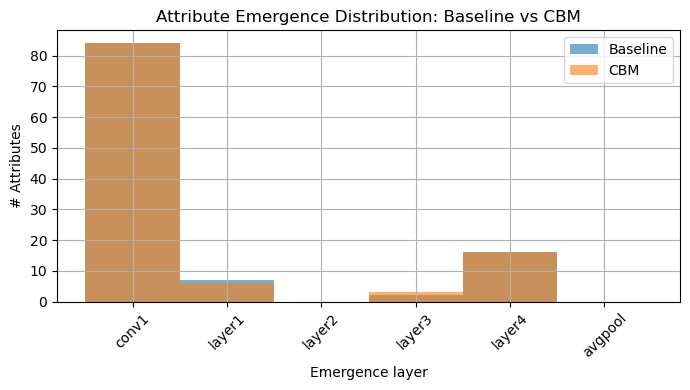

In [ ]:
# CELL 6 — Histogram of emergence depth indices (attributes)

bins = np.arange(-0.5, len(LAYER_ORDER) + 0.5, 1)

plt.figure()
plt.hist(attr_base["emergence_idx"], bins=bins, alpha=0.6, label="Baseline")
plt.hist(attr_cbm["emergence_idx"],  bins=bins, alpha=0.6, label="CBM")
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.xlabel("Emergence layer")
plt.ylabel("# Attributes")
plt.title("Attribute Emergence Distribution: Baseline vs CBM")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation 
- In the **baseline**, we saw that most attributes emerged at `conv1`,
  with very few peaking at intermediate layers.
- After **CBM training**, we expect one of three patterns:
  1. **No change:** CBM does not change where concepts live; it just makes them easier to decode.
  2. **Shift later:** attributes now tend to emerge in deeper layers, indicating a more compositional, mediated representation.
  3. **Mixed:** some attributes shift later (e.g., relational ones), while simple color attributes remain shallow.

We’ll now quantify that shift concept by concept.


In [ ]:
# CELL 7 — Merge baseline and CBM emergence for attribute-wise comparison

# Merge on (target_name, group, target_type == attribute)
merge_cols = ["target_type", "target_name", "group"]

merged = attr_base.merge(
    attr_cbm,
    on=merge_cols,
    suffixes=("_baseline", "_cbm"),
    how="inner",
)

print("Attributes present in both models:", merged.shape[0])
merged.head()


Attributes present in both models: 109


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0,cbm,0.790645,layer1,1
1,baseline,attribute,has_back_color::brown,has_back_color,0.833621,conv1,0,cbm,0.836210,conv1,0
2,baseline,attribute,has_back_color::buff,has_back_color,0.857094,conv1,0,cbm,0.860373,conv1,0
3,baseline,attribute,has_back_color::grey,has_back_color,0.773559,conv1,0,cbm,0.785123,conv1,0
4,baseline,attribute,has_back_color::white,has_back_color,0.866241,conv1,0,cbm,0.867967,conv1,0


Now we can look at the **change in emergence depth** for each attribute:

\[
\Delta_\text{depth} = \text{emergence\_idx}_\text{cbm} - \text{emergence\_idx}_\text{baseline}
\]

- If Δ_depth > 0 → attribute moved **deeper** under CBM supervision  
- If Δ_depth = 0 → emergence depth unchanged  
- If Δ_depth < 0 → attribute moved **shallower** (often rare)


In [ ]:
# CELL 8 — Compute per-attribute depth shift

merged["delta_depth"] = merged["emergence_idx_cbm"] - merged["emergence_idx_baseline"]
merged["delta_acc"]   = merged["max_acc_cbm"] - merged["max_acc_baseline"]

print("Depth shifts summary:")
print(merged["delta_depth"].describe())

merged.sort_values("delta_depth", ascending=False).head(10)


Depth shifts summary:
count    109.000000
mean       0.018349
std        0.429937
min       -1.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000
Name: delta_depth, dtype: float64


,model_baseline,target_type,target_name,group,max_acc_baseline,emergence_layer_baseline,emergence_idx_baseline,model_cbm,max_acc_cbm,emergence_layer_cbm,emergence_idx_cbm,delta_depth,delta_acc
73,baseline,attribute,has_throat_color::black,has_throat_color,0.862962,conv1,0,cbm,0.877459,layer4,4,4,0.014498
0,baseline,attribute,has_back_color::black,has_back_color,0.785468,conv1,0,cbm,0.790645,layer1,1,1,0.005178
81,baseline,attribute,has_under_tail_color::grey,has_under_tail_color,0.791681,conv1,0,cbm,0.795133,conv1,0,0,0.003452
79,baseline,attribute,has_under_tail_color::brown,has_under_tail_color,0.847256,conv1,0,cbm,0.851053,conv1,0,0,0.003797
78,baseline,attribute,has_under_tail_color::black,has_under_tail_color,0.743873,conv1,0,cbm,0.741974,conv1,0,0,-0.001899
76,baseline,attribute,has_throat_color::white,has_throat_color,0.792371,layer4,4,cbm,0.798585,layer4,4,0,0.006213
75,baseline,attribute,has_throat_color::grey,has_throat_color,0.834484,conv1,0,cbm,0.838626,conv1,0,0,0.004142
74,baseline,attribute,has_throat_color::buff,has_throat_color,0.869002,conv1,0,cbm,0.872109,conv1,0,0,0.003107
72,baseline,attribute,has_tail_shape::rounded_tail,has_tail_shape,0.887470,conv1,0,cbm,0.887642,conv1,0,0,0.000173
71,baseline,attribute,has_tail_shape::pointed_tail,has_tail_shape,0.819468,conv1,0,cbm,0.819296,conv1,0,0,-0.000173


### How to read this:

- `delta_depth` large and positive → attribute emerges later with CBM  
- `delta_depth` around 0 → CBM did not move its emergence location  
- `delta_depth` negative → unlikely, but means CBM shifted that concept earlier

We can visualize this in a scatter plot: baseline vs CBM depth.


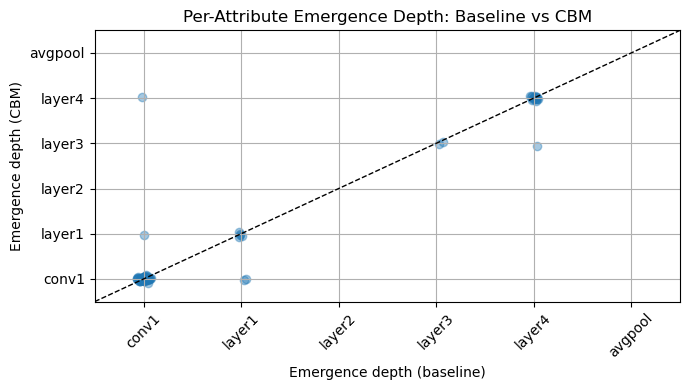

In [ ]:
# CELL 9 — Scatter: baseline vs CBM emergence depth for attributes

plt.figure()
plt.scatter(
    merged["emergence_idx_baseline"] + (np.random.randn(len(merged)) * 0.03),
    merged["emergence_idx_cbm"]      + (np.random.randn(len(merged)) * 0.03),
    alpha=0.4,
)
lims = [-0.5, len(LAYER_ORDER) - 0.5]
plt.plot(lims, lims, "k--", linewidth=1)  # diagonal y = x
plt.xlim(lims)
plt.ylim(lims)
plt.xticks(range(len(LAYER_ORDER)), LAYER_ORDER, rotation=45)
plt.yticks(range(len(LAYER_ORDER)), LAYER_ORDER)
plt.xlabel("Emergence depth (baseline)")
plt.ylabel("Emergence depth (CBM)")
plt.title("Per-Attribute Emergence Depth: Baseline vs CBM")
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation of the scatter

- Points **on the diagonal** → emergence depth unchanged.
- Points **above the diagonal** → attributes emerge **later** in the CBM backbone.
- Points **below the diagonal** → attributes moved earlier.

You can now visually check whether CBM tends to push attributes deeper.

Next, we look at semantic **groups** of attributes.


In [ ]:
# CELL 10 — Group-level mean depth per model

def group_stats(attr_df, label):
    return (
        attr_df.groupby("group")["emergence_idx"]
        .mean()
        .rename(f"mean_depth_{label}")
    )

group_base = group_stats(attr_base, "baseline")
group_cbm  = group_stats(attr_cbm,  "cbm")

group_compare = (
    pd.concat([group_base, group_cbm], axis=1)
      .dropna()
)

group_compare["delta_group_depth"] = group_compare["mean_depth_cbm"] - group_compare["mean_depth_baseline"]
group_compare.sort_values("delta_group_depth", ascending=False).head(15)


,mean_depth_baseline,mean_depth_cbm,delta_group_depth
group,,,
has_throat_color,1.000000,1.600000,0.6
has_back_color,0.000000,0.200000,0.2
has_back_pattern,0.000000,0.000000,0.0
has_wing_pattern,0.000000,0.000000,0.0
has_upperparts_color,0.800000,0.800000,0.0
has_upper_tail_color,0.000000,0.000000,0.0
has_underparts_color,0.833333,0.833333,0.0
has_under_tail_color,0.000000,0.000000,0.0
has_tail_shape,0.000000,0.000000,0.0


This table tells us, for example:

- Are **shape-related** groups (e.g., `has_bill_shape`, `has_tail_shape`, `has_size`)  
  the ones whose emergence depth increases most under CBM?
- Do **pure color groups** (e.g., `has_breast_color`, `has_back_color`, `has_wing_color`)  
  mostly stay shallow, even in CBM?

We can also visualize this shift by group.


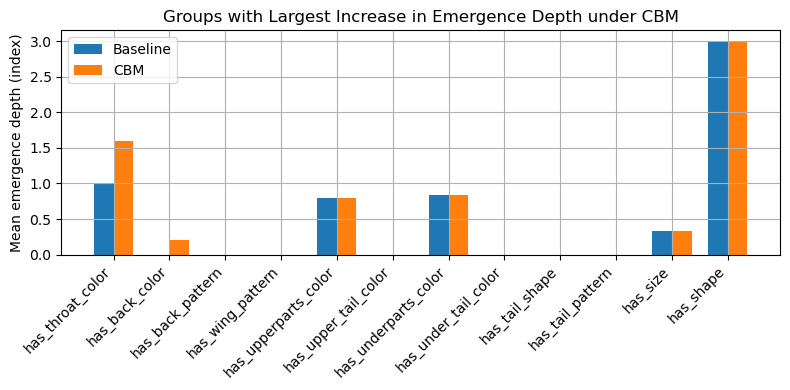

In [ ]:
# CELL 11 — Bar plot for group-level depth shifts

top_groups = (
    group_compare
    .sort_values("delta_group_depth", ascending=False)
    .head(12)
    .reset_index()
)

plt.figure(figsize=(8, 4))
x = np.arange(len(top_groups))
width = 0.35

plt.bar(x - width/2, top_groups["mean_depth_baseline"], width, label="Baseline")
plt.bar(x + width/2, top_groups["mean_depth_cbm"],      width, label="CBM")

plt.xticks(x, top_groups["group"], rotation=45, ha="right")
plt.ylabel("Mean emergence depth (index)")
plt.title("Groups with Largest Increase in Emergence Depth under CBM")
plt.legend()
plt.tight_layout()
plt.show()


Loaded baseline probes: (660, 9)
Loaded CBM probes: (660, 9)
Combined df shape: (1320, 9)
Columns: ['layer', 'target_type', 'target_name', 'group', 'train_acc', 'val_acc', 'best_val_acc', 'column', 'model']


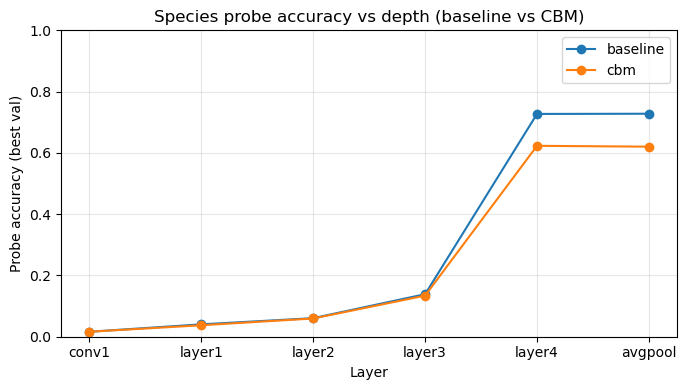

Plotting attributes: ['has_throat_color::black', 'has_back_color::black', 'has_shape::perching-like']


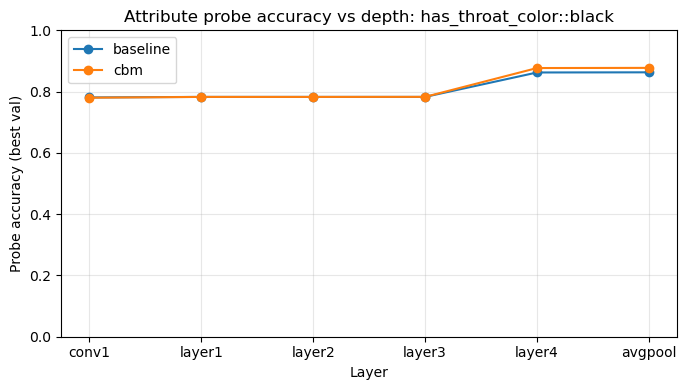

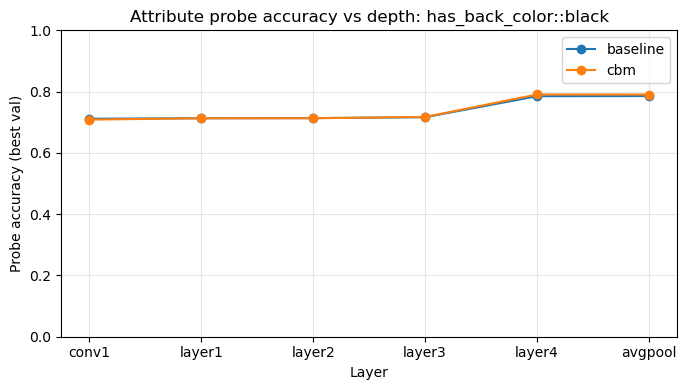

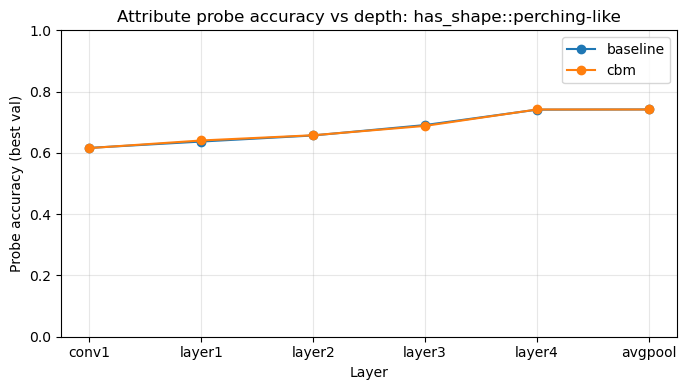

In [18]:
# =========================
# 1. Load probe results
# =========================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

dfs = []

if BASELINE_JSON.exists():
    with open(BASELINE_JSON, "r") as f:
        data = json.load(f)
    df_base = pd.DataFrame(data)
    df_base["model"] = "baseline"
    dfs.append(df_base)
    print("Loaded baseline probes:", df_base.shape)
else:
    print("Baseline JSON not found:", BASELINE_JSON)

if CBM_JSON.exists():
    with open(CBM_JSON, "r") as f:
        data = json.load(f)
    df_cbm = pd.DataFrame(data)
    df_cbm["model"] = "cbm"
    dfs.append(df_cbm)
    print("Loaded CBM probes:", df_cbm.shape)
else:
    print("CBM JSON not found:", CBM_JSON)

assert len(dfs) > 0, "No probe JSONs found — cannot proceed."

df = pd.concat(dfs, ignore_index=True)
print("Combined df shape:", df.shape)
print("Columns:", df.columns.tolist())


# =========================
# 2. Plot helpers
# =========================

LAYER_ORDER = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]

def plot_probe_curves(df, target_name, target_type, models=("baseline", "cbm"), title=None):
    sub = df[
        (df["target_name"] == target_name) &
        (df["target_type"] == target_type) &
        (df["model"].isin(models))
    ].copy()

    if sub.empty:
        print(f"[WARN] No data for {target_name}")
        return

    sub["layer"] = pd.Categorical(sub["layer"], categories=LAYER_ORDER, ordered=True)
    sub = sub.sort_values("layer")

    plt.figure(figsize=(7, 4))
    for m, dm in sub.groupby("model"):
        plt.plot(dm["layer"], dm["best_val_acc"], marker="o", label=m)

    plt.ylim(0, 1)
    plt.xlabel("Layer")
    plt.ylabel("Probe accuracy (best val)")
    plt.title(title if title else f"Probe accuracy vs depth: {target_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 3. Species curve
# =========================

plot_probe_curves(
    df,
    target_name="species",
    target_type="subclass",
    title="Species probe accuracy vs depth (baseline vs CBM)"
)


# =========================
# 4. Attribute curves
# =========================

attrs_to_plot = [
    "has_throat_color::black",
    "has_back_color::black",
    "has_bill_length::longer_than_head",
    "has_shape::perching-like",
]

existing_attrs = set(
    df.loc[df["target_type"] == "attribute", "target_name"].unique()
)
attrs_to_plot = [a for a in attrs_to_plot if a in existing_attrs]

print("Plotting attributes:", attrs_to_plot)

for attr in attrs_to_plot:
    plot_probe_curves(
        df,
        target_name=attr,
        target_type="attribute",
        title=f"Attribute probe accuracy vs depth: {attr}"
    )
# wow chatgpt rly spits out code without restraint

In [2]:
!pip install numpy
!pip install matplotlib
!pip install pandas
import sys, os
sys.path.append(os.path.abspath(".."))

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 8.6 MB/s            
     |████████████████████████████████| 4.8 MB 187.0 MB/s            
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 12.8 MB 8.0 MB/s            
     |████████████████████████████████| 348 kB 168.9 MB/s            
     |████████████████████████████████| 509 kB 161.9 MB/s            
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
open3d 0.18.0 requires scikit-learn>=0.21, which is not installed.


Loaded probe results with shape: (660, 8)
Columns: ['layer', 'target_type', 'target_name', 'group', 'train_acc', 'val_acc', 'best_val_acc', 'column']

Mean emergence depth vs threshold:


,threshold,emergence_idx
0,0.95,1.559633
1,0.96,1.844037
2,0.97,2.229358
3,0.98,2.587156
4,0.99,2.926606


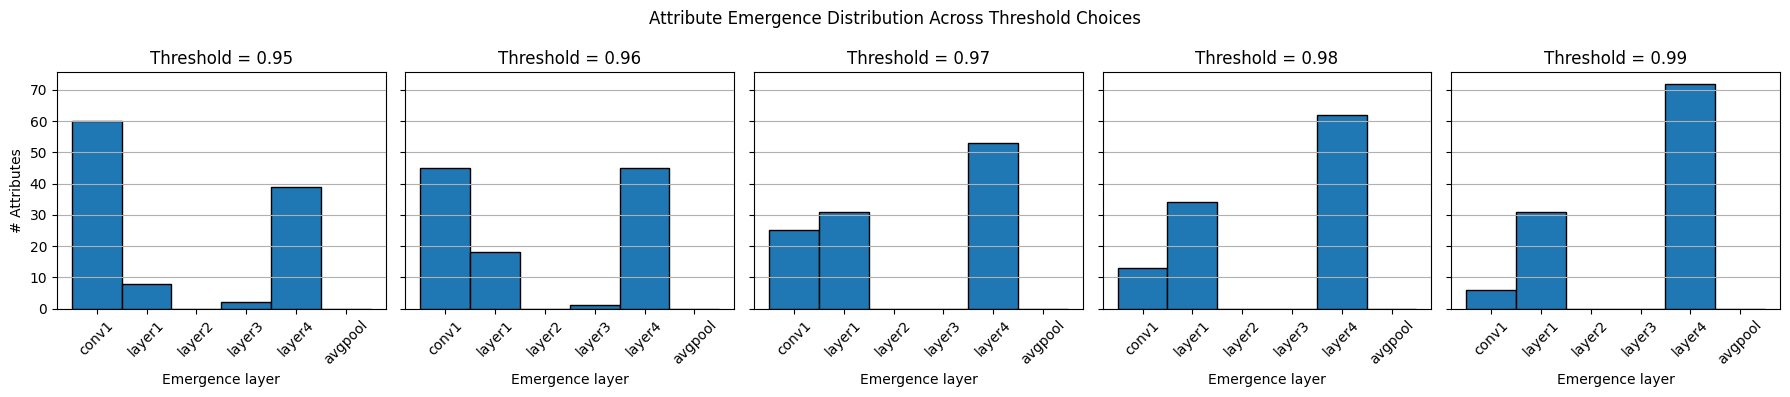


Attributes most sensitive to threshold choice:


threshold,0.95,0.96,0.97,0.98,0.99,range
target_name,,,,,,
has_back_color::brown,0,1,1,4,4,4
has_upperparts_color::grey,0,4,4,4,4,4
has_upperparts_color::buff,0,0,1,1,4,4
has_upperparts_color::white,0,1,4,4,4,4
has_bill_shape::dagger,0,0,0,1,4,4
has_breast_color::buff,0,0,1,4,4,4
has_underparts_color::grey,0,0,1,1,4,4
has_underparts_color::buff,0,0,1,4,4,4
has_crown_color::brown,0,1,4,4,4,4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. LOAD PROBE RESULTS
# ============================================================

# Adjust path if needed
PROBE_PATH = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")

if not PROBE_PATH.exists():
    raise FileNotFoundError(f"Could not find probe results at {PROBE_PATH}")

df = pd.read_json(PROBE_PATH)

print("Loaded probe results with shape:", df.shape)
print("Columns:", df.columns.tolist())

# Keep only baseline attribute probes
df = df[(df["target_type"] == "attribute")]

# ============================================================
# 2. SET UP LAYER ORDERING
# ============================================================

layer_order = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
layer_to_idx = {l: i for i, l in enumerate(layer_order)}

df = df.copy()
df["layer_idx"] = df["layer"].map(layer_to_idx)

# Sanity check
assert df["layer_idx"].isnull().sum() == 0, "Unmapped layer names detected"

# ============================================================
# 3. EMERGENCE COMPUTATION FUNCTION
# ============================================================

def compute_emergence(df_sub, threshold):
    rows = []

    for target, g in df_sub.groupby("target_name"):
        g = g.sort_values("layer_idx")
        max_acc = g["best_val_acc"].max()
        cutoff = threshold * max_acc

        emerged = g[g["best_val_acc"] >= cutoff]
        if len(emerged) == 0:
            continue

        first = emerged.iloc[0]
        rows.append({
            "target_name": target,
            "emergence_layer": first["layer"],
            "emergence_idx": first["layer_idx"],
            "threshold": threshold
        })

    return pd.DataFrame(rows)

# ============================================================
# 4. RUN FOR MULTIPLE THRESHOLDS
# ============================================================

thresholds = [0.95, 0.96, 0.97, 0.98, 0.99]

emergence_all = []
for t in thresholds:
    out = compute_emergence(df, t)
    emergence_all.append(out)

emergence_df = pd.concat(emergence_all, ignore_index=True)

# ============================================================
# 5. SUMMARY STATISTICS
# ============================================================

summary = (
    emergence_df
    .groupby("threshold")["emergence_idx"]
    .mean()
    .reset_index()
)

print("\nMean emergence depth vs threshold:")
display(summary)

# ============================================================
# 6. DISTRIBUTION PLOTS
# ============================================================

fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 4), sharey=True)

for ax, t in zip(axes, thresholds):
    subset = emergence_df[emergence_df["threshold"] == t]
    ax.hist(
        subset["emergence_idx"],
        bins=np.arange(-0.5, len(layer_order) + 0.5, 1),
        edgecolor="black"
    )
    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels(layer_order, rotation=45)
    ax.set_title(f"Threshold = {t}")
    ax.set_xlabel("Emergence layer")
    ax.grid(True, axis="y")

axes[0].set_ylabel("# Attributes")
plt.suptitle("Attribute Emergence Distribution Across Threshold Choices")
plt.tight_layout()
plt.show()

# ============================================================
# 7. WHICH ATTRIBUTES MOVE MOST?
# ============================================================

pivot = emergence_df.pivot(
    index="target_name",
    columns="threshold",
    values="emergence_idx"
)

pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

print("\nAttributes most sensitive to threshold choice:")
display(pivot.sort_values("range", ascending=False).head(10))


Loaded df_all: (1320, 10)
Models: ['baseline' 'cbm']
Target types: ['subclass' 'attribute']
Attributes we will plot (exist in df): ['has_throat_color::black', 'has_back_color::black', 'has_shape::perching-like']


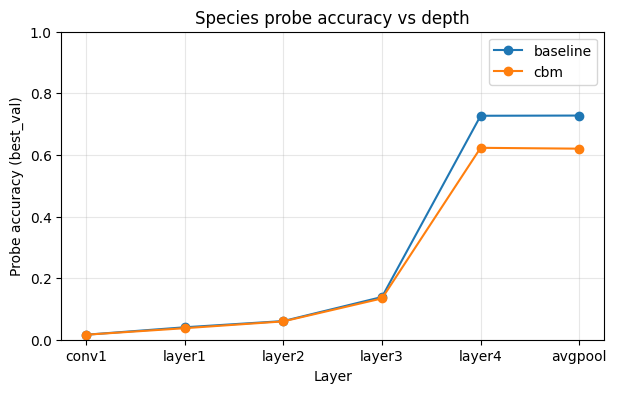

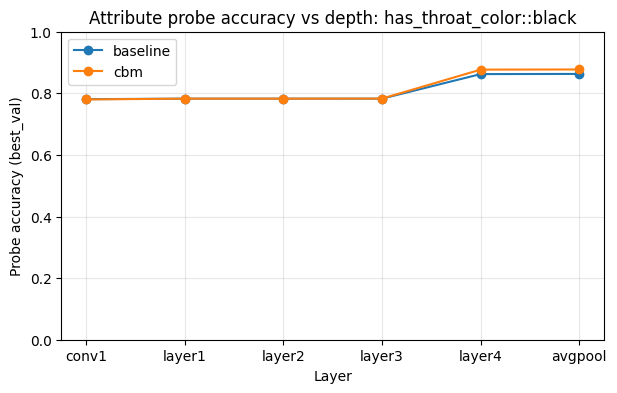

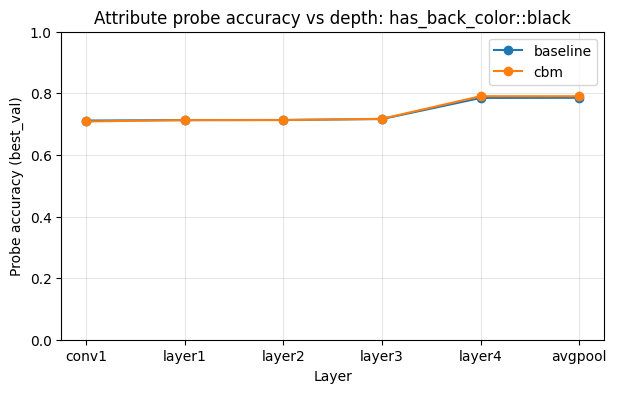

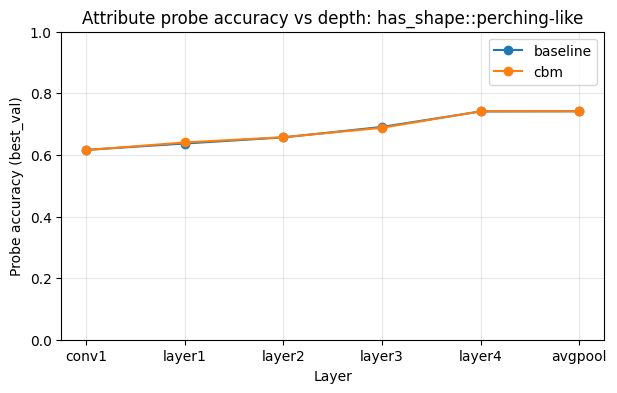

,model,target_type,target_name,max_acc,sharp_rise_layer,emerge_0.50,emerge_0.70,emerge_0.80,emerge_0.90,emerge_0.95
0,baseline,subclass,species,0.727822,layer4,layer4,layer4,layer4,layer4,layer4
1,cbm,subclass,species,0.623058,layer4,layer4,layer4,layer4,layer4,layer4
2,baseline,attribute,has_throat_color::black,0.862962,layer4,conv1,conv1,conv1,conv1,layer4
3,cbm,attribute,has_throat_color::black,0.877459,layer4,conv1,conv1,conv1,layer4,layer4
4,baseline,attribute,has_back_color::black,0.785468,layer4,conv1,conv1,conv1,conv1,layer4
5,cbm,attribute,has_back_color::black,0.790645,layer4,conv1,conv1,conv1,layer1,layer4
6,baseline,attribute,has_shape::perching-like,0.741802,layer4,conv1,conv1,conv1,layer3,layer4
7,cbm,attribute,has_shape::perching-like,0.741629,layer4,conv1,conv1,conv1,layer3,layer4



Fraction of attributes where emergence(alpha=0.90) == sharp-rise layer:
model
baseline    0.165138
cbm         0.155963
dtype: float64

Fraction of attributes where emergence(alpha=0.95) == sharp-rise layer:
model
baseline    0.412844
cbm         0.495413
dtype: float64

Examples where sharp-rise != emergence(0.90):


,model,attr,sharp_rise,emerge_0.90,emerge_0.95
0,baseline,has_back_color::black,layer4,conv1,layer4
1,baseline,has_back_color::brown,layer4,conv1,conv1
2,baseline,has_back_color::buff,layer1,conv1,conv1
3,baseline,has_back_color::grey,layer4,conv1,conv1
4,baseline,has_back_color::white,layer1,conv1,layer1
5,baseline,has_back_pattern::multi-colored,layer1,conv1,conv1
6,baseline,has_back_pattern::solid,layer4,conv1,layer4
7,baseline,has_back_pattern::striped,layer1,conv1,conv1
8,baseline,has_belly_color::black,layer4,conv1,layer1
9,baseline,has_belly_color::buff,layer1,conv1,conv1


In [16]:
# ============================
# Emergence-threshold sanity checks + "sharp rise" analysis
# Paste this as ONE cell in your notebook.
# ============================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Paths (edit if needed)
# -----------------------------
BASELINE_JSON = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_probes_attributes.json")
CBM_JSON      = Path("/scratch/network/cr7998/cv_emergence_project/results/probes/resnet50_cub_cbm_probes_attributes.json")

assert BASELINE_JSON.exists(), f"Missing {BASELINE_JSON}"
assert CBM_JSON.exists(), f"Missing {CBM_JSON}"

# -----------------------------
# 1) Load JSONs into one dataframe
# -----------------------------
def load_probe_json(path: Path, model_name: str) -> pd.DataFrame:
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["model"] = model_name
    return df

df_all = pd.concat([
    load_probe_json(BASELINE_JSON, "baseline"),
    load_probe_json(CBM_JSON, "cbm"),
], ignore_index=True)

# Basic sanity
needed_cols = {"layer", "target_type", "target_name", "best_val_acc", "model"}
missing = needed_cols - set(df_all.columns)
assert not missing, f"Missing required columns in JSON: {missing}"

layer_order = ["conv1", "layer1", "layer2", "layer3", "layer4", "avgpool"]
layer_to_idx = {l: i for i, l in enumerate(layer_order)}
df_all = df_all[df_all["layer"].isin(layer_order)].copy()
df_all["layer_idx"] = df_all["layer"].map(layer_to_idx)

print("Loaded df_all:", df_all.shape)
print("Models:", df_all["model"].unique())
print("Target types:", df_all["target_type"].unique())

# -----------------------------
# 2) Helper: get accuracy curve for one target (per model)
# -----------------------------
def get_curve(df: pd.DataFrame, target_type: str, target_name: str, model: str) -> pd.Series:
    sub = df[(df["model"] == model) &
             (df["target_type"] == target_type) &
             (df["target_name"] == target_name)].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    # If there are duplicates per layer for some reason, take max best_val_acc per layer.
    sub = sub.groupby("layer", as_index=False)["best_val_acc"].max()
    sub["layer_idx"] = sub["layer"].map(layer_to_idx)
    sub = sub.sort_values("layer_idx")
    curve = pd.Series(sub["best_val_acc"].values, index=sub["layer"].values)
    # Reindex to full layer_order (may introduce NaN if a layer missing)
    curve = curve.reindex(layer_order)
    return curve

# -----------------------------
# 3) Emergence depth given threshold α
#    "First layer whose acc >= α * max_acc"
# -----------------------------
def emergence_layer_from_threshold(curve: pd.Series, alpha: float) -> str:
    vals = curve.values.astype(float)
    if np.all(np.isnan(vals)):
        return None
    max_acc = np.nanmax(vals)
    if np.isnan(max_acc) or max_acc <= 0:
        return None
    thresh = alpha * max_acc
    for layer, acc in curve.items():
        if pd.notna(acc) and acc >= thresh:
            return layer
    return None

# -----------------------------
# 4) "Sharp rise" layer from the curve itself
#    We define as argmax of Δacc between consecutive layers.
#    (returns the *later* layer at which the jump is realized)
# -----------------------------
def sharp_rise_layer(curve: pd.Series) -> str:
    vals = curve.values.astype(float)
    if np.all(np.isnan(vals)):
        return None
    # forward-fill NaNs so diff isn't broken if a layer missing
    vals_ff = pd.Series(vals).ffill().bfill()
    diffs = np.diff(vals_ff)  # length 5 (between 6 layers)
    j = int(np.argmax(diffs))
    # jump is from layer_order[j] -> layer_order[j+1]
    return layer_order[j+1]

def plot_curve(curve_baseline: pd.Series, curve_cbm: pd.Series, title: str):
    x = np.arange(len(layer_order))
    plt.figure(figsize=(7, 4))
    plt.plot(x, curve_baseline.values, marker="o", label="baseline")
    plt.plot(x, curve_cbm.values, marker="o", label="cbm")
    plt.xticks(x, layer_order, rotation=0)
    plt.ylim(0, 1.0)
    plt.xlabel("Layer")
    plt.ylabel("Probe accuracy (best_val)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# -----------------------------
# 5) Choose targets to inspect
#    Edit this list freely.
# -----------------------------
attrs_to_plot = [
    "has_throat_color::black",
    "has_back_color::black",
    "has_shape::perching-like",
]
species_name = "species"

# Filter to existing attribute names so you don't get empty plots
existing_attrs = set(df_all.loc[df_all["target_type"] == "attribute", "target_name"].unique())
attrs_to_plot = [a for a in attrs_to_plot if a in existing_attrs]
print("Attributes we will plot (exist in df):", attrs_to_plot)

# -----------------------------
# 6) Plot raw accuracy-vs-layer curves (this answers your “show me acc vs layer” ask)
# -----------------------------
# Species curve
curve_sp_base = get_curve(df_all, "subclass", species_name, "baseline")
curve_sp_cbm  = get_curve(df_all, "subclass", species_name, "cbm")
plot_curve(curve_sp_base, curve_sp_cbm, "Species probe accuracy vs depth")

# Attribute curves
for a in attrs_to_plot:
    c0 = get_curve(df_all, "attribute", a, "baseline")
    c1 = get_curve(df_all, "attribute", a, "cbm")
    plot_curve(c0, c1, f"Attribute probe accuracy vs depth: {a}")

# -----------------------------
# 7) Threshold test: does emergence land on the sharp rise?
#    For each target, compare:
#      - sharp-rise layer (from Δacc)
#      - emergence layer for multiple alphas
# -----------------------------
alphas = [0.50, 0.70, 0.80, 0.90, 0.95]

def threshold_vs_jump_table(target_type: str, target_name: str) -> pd.DataFrame:
    rows = []
    for model in ["baseline", "cbm"]:
        curve = get_curve(df_all, target_type, target_name, model)
        jump = sharp_rise_layer(curve)
        max_acc = float(np.nanmax(curve.values)) if not np.all(np.isnan(curve.values)) else np.nan
        row = {"model": model, "target_type": target_type, "target_name": target_name, "max_acc": max_acc, "sharp_rise_layer": jump}
        for a in alphas:
            row[f"emerge_{a:.2f}"] = emergence_layer_from_threshold(curve, a)
        rows.append(row)
    return pd.DataFrame(rows)

# Show for species + your chosen attributes
tables = []
tables.append(threshold_vs_jump_table("subclass", "species"))
for a in attrs_to_plot:
    tables.append(threshold_vs_jump_table("attribute", a))

summary_tbl = pd.concat(tables, ignore_index=True)
display(summary_tbl)

# -----------------------------
# 8) Global check over ALL attributes:
#    How often does the alpha=0.90 emergence layer equal the sharp-rise layer?
#    (This directly answers your prof’s concern in one number.)
# -----------------------------
all_attrs = sorted(existing_attrs)
rows = []
for model in ["baseline", "cbm"]:
    for a in all_attrs:
        curve = get_curve(df_all, "attribute", a, model)
        if curve.empty or np.all(np.isnan(curve.values)):
            continue
        jump = sharp_rise_layer(curve)
        em90 = emergence_layer_from_threshold(curve, 0.90)
        em95 = emergence_layer_from_threshold(curve, 0.95)
        rows.append({"model": model, "attr": a, "sharp_rise": jump, "emerge_0.90": em90, "emerge_0.95": em95})

global_tbl = pd.DataFrame(rows)
match90 = (global_tbl["sharp_rise"] == global_tbl["emerge_0.90"]).groupby(global_tbl["model"]).mean()
match95 = (global_tbl["sharp_rise"] == global_tbl["emerge_0.95"]).groupby(global_tbl["model"]).mean()

print("\nFraction of attributes where emergence(alpha=0.90) == sharp-rise layer:")
print(match90)
print("\nFraction of attributes where emergence(alpha=0.95) == sharp-rise layer:")
print(match95)

# Optional: show where they differ (top 20)
diffs = global_tbl[global_tbl["sharp_rise"] != global_tbl["emerge_0.90"]].copy()
print("\nExamples where sharp-rise != emergence(0.90):")
display(diffs.head(20))
